# 25 · `timeseries`

`temporal.TimeSeries` reduces each member of a `DatasetCollection` to one value per step (default: spatial mean) and plots the curve.

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
import numpy as np
from pyramids.dataset.collection import DatasetCollection
z = np.nan_to_num(ds.read_array(band=0).astype('float32'))
rng = np.random.default_rng(0)
members = [Dataset.create_from_array(arr=(z * f + rng.normal(0, 4, z.shape)).astype('float32'),
                                     geo=ds.geotransform, epsg=ds.epsg)
           for f in np.linspace(0.4, 1.0, 8)]
dc = DatasetCollection(members[0], len(members), datasets=members)
from digitalearth.temporal import TimeSeries
import matplotlib.pyplot as plt

2026-05-28 20:31:18 | INFO | pyramids.base.config | Logging is configured.


Plot the per-member spatial mean.

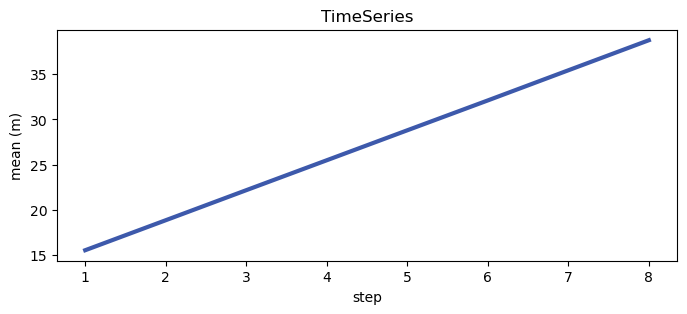

In [2]:
fig, ax = plt.subplots(figsize=(8, 3))
TimeSeries(dc).plot(times=list(range(1, 9)), ax=ax)
ax.set(xlabel='step', ylabel='mean (m)', title='TimeSeries')
fig;